# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [3]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [4]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
Map: 100%|██████████| 25000/25000 [00:04<00:00, 5434.50 examples/s]
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83488


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [5]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.74812


We can save the current checkpoint for future reference (optional).

In [7]:
from pathlib import Path

mg.export(f"{Path.home()}/tutorial_3_ptq")

INFO     Exporting MaseGraph to /root/tutorial_3_ptq.pt, /root/tutorial_3_ptq.mz
INFO     Exporting GraphModule to /root/tutorial_3_ptq.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /root/tutorial_3_ptq.mz


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [8]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.404400
1000,0.394500
1500,0.405000
2000,0.387900
2500,0.389100
3000,0.390400


Evaluation accuracy: 0.84044


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [9]:
from pathlib import Path

mg.export(f"{Path.home()}/tutorial_3_qat")

INFO     Exporting MaseGraph to /root/tutorial_3_qat.pt, /root/tutorial_3_qat.mz
INFO     Exporting GraphModule to /root/tutorial_3_qat.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /root/tutorial_3_qat.mz


# Task 1

In Tutorial 3, you quantized every Linear layer in the model to the provided configuration. Now, explore a range of fixed point widths from 4 to 32. 

a. Plot a figure where the x-axis is the fixed point width and the y-axis is the highest achieved accuracy on the IMDb dataset, following the procedure in Tutorial 3.

b. Plot separate curves for PTQ and QAT at each precision to show the effect of post-quantization finetuning.

In [1]:
# Load original model

checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from transformers import AutoModelForSequenceClassification

import json
from pathlib import Path

import chop.passes as passes
from chop import MaseGraph
from chop import MaseGraph
from chop.tools import get_tokenized_dataset, get_trainer

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)
mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /root/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Mon Jan 26 16:32:36 2026).
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [2]:
import copy
import math
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Define the widths to sweep
# ----------------------------
widths = [4, 6, 8, 10, 12, 16, 24, 32]  # change as needed (use even widths if frac=W/2)

# ----------------------------
# Keep a pristine, float (unquantized) graph/model to copy from each run
# ----------------------------
mg_fp = copy.deepcopy(mg) 

# ----------------------------
# Storage for results
# ----------------------------
results = []  # list of dict rows

for W in widths:
    F = W // 2  # assumption: frac width always half total width

    quantization_config = {
        "by": "type",
        "default": {"config": {"name": None}},
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": W,
                "data_in_frac_width": F,
                # weight
                "weight_width": W,
                "weight_frac_width": F,
                # bias
                "bias_width": W,
                "bias_frac_width": F,
            }
        },
    }

    # -------------
    # Fresh copy per width
    # -------------
    mg_run = copy.deepcopy(mg_fp)

    # Apply quantization transform pass
    mg_run, _ = passes.quantize_transform_pass(
        mg_run,
        pass_args=quantization_config,
    )

    # -------------
    # Evaluate after PTA
    # -------------
    trainer = get_trainer(
        model=mg_run.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    eval_pta = trainer.evaluate()
    acc_pta = float(eval_pta["eval_accuracy"])
    print(f"[W={W}, F={F}] Accuracy after PTA: {acc_pta}")

    # -------------
    # Train (QAT) then evaluate after QAT
    # -------------
    trainer.train()
    eval_qat = trainer.evaluate()
    acc_qat = float(eval_qat["eval_accuracy"])
    print(f"[W={W}, F={F}] Accuracy after QAT: {acc_qat}")

    results.append(
        {
            "width": W,
            "frac_width": F,
            "acc_pta": acc_pta,
            "acc_qat": acc_qat,
            "acc_best": max(acc_pta, acc_qat),
        }
    )

# ----------------------------
# Put results into a table
# ----------------------------
df = pd.DataFrame(results).sort_values("width")
print(df)


json_path = "accuracy_vs_fixed_point_width.json"

with open(json_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {json_path}")

/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[W=4, F=2] Accuracy after PTA: 0.5


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


[W=4, F=2] Accuracy after QAT: 0.5


/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

[W=24, F=12] Accuracy after QAT: 0.84168


/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[W=32, F=16] Accuracy after PTA: 0.83488


Step,Training Loss
500,0.389100
1000,0.383400
1500,0.396400
2000,0.377400
2500,0.380600
3000,0.382800


[W=32, F=16] Accuracy after QAT: 0.84148
   width  frac_width  acc_pta  acc_qat  acc_best
0      4           2  0.50000  0.50000   0.50000
1      6           3  0.67508  0.83172   0.83172
2      8           4  0.74812  0.84044   0.84044
3     10           5  0.82736  0.84032   0.84032
4     12           6  0.83268  0.84164   0.84164
5     16           8  0.83360  0.84204   0.84204
6     24          12  0.83484  0.84168   0.84168
7     32          16  0.83488  0.84148   0.84148
Results saved to accuracy_vs_fixed_point_width.json


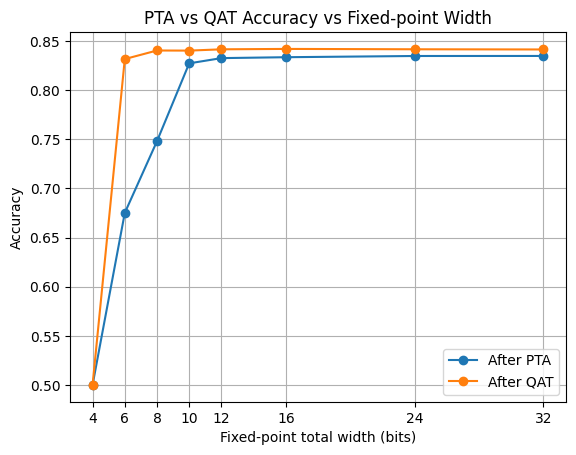

In [3]:
# ----------------------------
# 5) Plot: x = fixed-point width, y = highest achieved accuracy
# ----------------------------
'''plt.figure()
plt.plot(df["width"], df["acc_best"], marker="o")
plt.xlabel("Fixed-point total width (bits)")
plt.ylabel("Highest achieved accuracy (max of PTA, QAT)")
plt.title("Accuracy vs Fixed-point Width")
plt.xticks(df["width"])
plt.grid(True)
plt.show()'''

plt.figure()
plt.plot(df["width"], df["acc_pta"], marker="o", label="After PTA")
plt.plot(df["width"], df["acc_qat"], marker="o", label="After QAT")
plt.xlabel("Fixed-point total width (bits)")
plt.ylabel("Accuracy")
plt.title("PTA vs QAT Accuracy vs Fixed-point Width")
plt.xticks(df["width"])
plt.grid(True)
plt.legend()
plt.show()

# Best Model

In [2]:
import copy
import math
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Define the widths to sweep
# ----------------------------
widths = [16]  # change as needed (use even widths if frac=W/2)

# ----------------------------
# Keep a pristine, float (unquantized) graph/model to copy from each run
# ----------------------------
mg_fp = copy.deepcopy(mg) 

# ----------------------------
# Storage for results
# ----------------------------
results = []  # list of dict rows

for W in widths:
    F = W // 2  # assumption: frac width always half total width

    quantization_config = {
        "by": "type",
        "default": {"config": {"name": None}},
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": W,
                "data_in_frac_width": F,
                # weight
                "weight_width": W,
                "weight_frac_width": F,
                # bias
                "bias_width": W,
                "bias_frac_width": F,
            }
        },
    }

    # -------------
    # Fresh copy per width
    # -------------
    mg_run = copy.deepcopy(mg_fp)

    # Apply quantization transform pass
    mg_run, _ = passes.quantize_transform_pass(
        mg_run,
        pass_args=quantization_config,
    )

    # -------------
    # Evaluate after PTA
    # -------------
    trainer = get_trainer(
        model=mg_run.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    eval_pta = trainer.evaluate()
    acc_pta = float(eval_pta["eval_accuracy"])
    print(f"[W={W}, F={F}] Accuracy after PTA: {acc_pta}")

    # -------------
    # Train (QAT) then evaluate after QAT
    # -------------
    trainer.train()
    eval_qat = trainer.evaluate()
    acc_qat = float(eval_qat["eval_accuracy"])
    print(f"[W={W}, F={F}] Accuracy after QAT: {acc_qat}")

    results.append(
        {
            "width": W,
            "frac_width": F,
            "acc_pta": acc_pta,
            "acc_qat": acc_qat,
            "acc_best": max(acc_pta, acc_qat),
        }
    )

# ----------------------------
# Save best model
# ----------------------------
mg_run.export(f"{Path.home()}/tutorial_3_best_model")

/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[W=16, F=8] Accuracy after PTA: 0.8336


Step,Training Loss
500,0.389200
1000,0.383400
1500,0.397200
2000,0.377700
2500,0.380700
3000,0.383500


INFO     Exporting MaseGraph to /root/tutorial_3_best_model.pt, /root/tutorial_3_best_model.mz
INFO     Exporting GraphModule to /root/tutorial_3_best_model.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /root/tutorial_3_best_model.mz


[W=16, F=8] Accuracy after QAT: 0.84184
